In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision.datasets import CIFAR10
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score
from tqdm import tqdm
import warnings

# 忽略警告信息
warnings.filterwarnings('ignore')

# 设置随机种子以保证结果可复现
torch.manual_seed(42)
np.random.seed(42)

# 检查是否有可用的GPU，否则使用CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


train_data: (50000, 32, 32, 3) uint8
train_label: (50000,) int64
test_data: (10000, 32, 32, 3) uint8
test_label: (10000,) int64


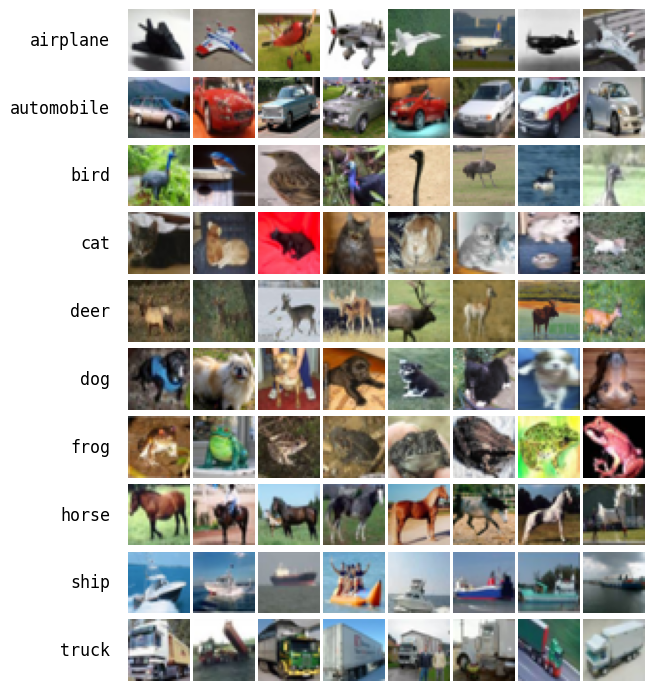

In [2]:
def load_cifar10_numpy(root="data"):
    """加载CIFAR-10数据集并转换为Numpy格式"""
    # 下载并加载训练集和测试集
    train_ds = CIFAR10(root=root, train=True, download=True)
    test_ds  = CIFAR10(root=root, train=False, download=True)

    # 提取数据和标签并转换为numpy数组
    train_data  = np.array(train_ds.data)        # (50000, 32, 32, 3)
    train_label = np.array(train_ds.targets).astype(np.int64)
    test_data   = np.array(test_ds.data)         # (10000, 32, 32, 3)
    test_label  = np.array(test_ds.targets).astype(np.int64)
    return train_data, train_label, test_data, test_label

# 加载数据
train_data, train_label, test_data, test_label = load_cifar10_numpy(root="data")
print("train_data:", train_data.shape, train_data.dtype)
print("train_label:", train_label.shape, train_label.dtype)
print("test_data:", test_data.shape, test_data.dtype)
print("test_label:", test_label.shape, test_label.dtype)

# CIFAR-10类别名称
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 
               'dog', 'frog', 'horse', 'ship', 'truck']


class CIFAR10Dataset(Dataset):
    """自定义Dataset类，用于PyTorch数据加载"""
    def __init__(self, data, labels, train=True):
        self.data = data
        self.labels = labels.astype(np.int64)
        self.train = train

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        # CIFAR-10: (H, W, C) uint8 -> (C, H, W) float32
        x = self.data[idx].astype(np.float32) / 255.0
        if self.train and np.random.rand() > 0.5:
            x = np.flip(x, axis=1).copy()  # 沿宽度方向翻转
        x = np.transpose(x, (2, 0, 1))
        y = self.labels[idx]
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)

# 实例化Dataset对象
train_dataset = CIFAR10Dataset(train_data, train_label, train=True)
test_dataset  = CIFAR10Dataset(test_data, test_label, train=False)

# 可视化部分样本
num_samples_per_class = 8
num_classes = 10
class_indices = {i: [] for i in range(num_classes)}
for idx, label in enumerate(train_label):
    if len(class_indices[label]) < num_samples_per_class:
        class_indices[label].append(idx)
    if all(len(indices) >= num_samples_per_class for indices in class_indices.values()):
        break
fig, axes = plt.subplots(num_classes, num_samples_per_class, figsize=(6, 7))
fig.patch.set_facecolor('white')
for class_idx in range(num_classes):
    for sample_idx in range(num_samples_per_class):
        ax = axes[class_idx, sample_idx]
        data_idx = class_indices[class_idx][sample_idx]
        img = train_data[data_idx] 
        ax.imshow(img)
        ax.axis('off')
    axes[class_idx, 0].text(-0.3, 0.5, class_names[class_idx], 
                            transform=axes[class_idx, 0].transAxes,
                            fontsize=12, verticalalignment='center',
                            horizontalalignment='right', fontfamily='monospace')
plt.subplots_adjust(left=0.12, right=0.98, top=0.98, bottom=0.02, wspace=0.05, hspace=0.1)
plt.show()


In [3]:
class CNN(nn.Module):
    """卷积神经网络
    
    参数:
        conv_channels: 卷积层通道数列表，例如[32, 64]
        kernel_size: 卷积核大小
        pool_type: 池化类型 ('max' 或 'avg')
        activation: 激活函数类型
        use_bn: 是否使用批归一化
        dropout_rate: Dropout比率 (0表示不使用)
        fc_sizes: 全连接层大小列表
    """
    def __init__(
            self, 
            conv_channels=[32, 64],
            kernel_size=3,
            pool_type='max',
            activation='relu',
            use_bn=True,
            dropout_rate=0.2,
            fc_sizes=[128],
            num_classes=10,
            ):
        super(CNN, self).__init__()
        
        # 保存配置
        self.conv_channels = conv_channels
        self.kernel_size = kernel_size
        self.pool_type = pool_type
        self.activation = activation
        self.use_bn = use_bn
        self.dropout_rate = dropout_rate
        self.fc_sizes = fc_sizes
        
        # 选择激活函数
        def get_activation():
            if activation == 'relu':
                return nn.ReLU()
            elif activation == 'sigmoid':
                return nn.Sigmoid()
            elif activation == 'tanh':
                return nn.Tanh()
            elif activation == 'leaky_relu':
                return nn.LeakyReLU(0.1)
            elif activation == 'elu':
                return nn.ELU()
            else:
                return nn.ReLU()
        
        # 选择池化层
        def get_pool():
            if pool_type == 'max':
                return nn.MaxPool2d(kernel_size=2, stride=2)
            elif pool_type == 'avg':
                return nn.AvgPool2d(kernel_size=2, stride=2)
            else:
                return nn.MaxPool2d(kernel_size=2, stride=2)
        
        # 构建卷积层
        conv_layers = []
        in_channels = 3  # CIFAR-10是RGB图像
        padding = kernel_size // 2  # same padding
        
        for out_channels in conv_channels:
            conv_layers.append(nn.Conv2d(in_channels, out_channels, 
                                         kernel_size=kernel_size, padding=padding))
            if use_bn:
                conv_layers.append(nn.BatchNorm2d(out_channels))
            conv_layers.append(get_activation())
            conv_layers.append(get_pool())
            if dropout_rate > 0:
                conv_layers.append(nn.Dropout2d(dropout_rate))
            in_channels = out_channels
        
        self.conv_layers = nn.Sequential(*conv_layers)
        
        # 计算卷积层输出的特征图大小
        # 输入: 32x32, 每次池化后尺寸减半
        feature_size = 32 // (2 ** len(conv_channels))
        self.flatten_size = conv_channels[-1] * feature_size * feature_size
        
        # 构建全连接层
        fc_layers = []
        prev_size = self.flatten_size
        
        for fc_size in fc_sizes:
            fc_layers.append(nn.Linear(prev_size, fc_size))
            if use_bn:
                fc_layers.append(nn.BatchNorm1d(fc_size))
            fc_layers.append(get_activation())
            if dropout_rate > 0:
                fc_layers.append(nn.Dropout(dropout_rate))
            prev_size = fc_size
        
        fc_layers.append(nn.Linear(prev_size, num_classes))
        self.fc_layers = nn.Sequential(*fc_layers)
        
    def forward(self, x):
        """前向传播"""
        x = self.conv_layers(x)
        x = x.view(x.size(0), -1)  # Flatten
        x = self.fc_layers(x)
        return x
    
def create_model(cfg):
    """根据配置字典创建模型实例"""
    model = CNN(
        conv_channels=cfg.get("conv_channels", [32, 64]),
        kernel_size=cfg.get("kernel_size", 3),
        pool_type=cfg.get("pool_type", "max"),
        activation=cfg.get("activation", "relu"),
        use_bn=cfg.get("use_bn", True),
        dropout_rate=cfg.get("dropout_rate", 0.2),
        fc_sizes=cfg.get("fc_sizes", [128]),
        num_classes=cfg.get("num_classes", 10),
    )
    return model.to(device)


In [4]:
def train_model(model, config, num_epochs=50):
    """训练模型"""
    # 配置信息
    name = config['name']
    batch_size = config.get('batch_size', 128)
    learning_rate = config.get('learning_rate', 1e-3)
    
    # 创建日志文件夹和文件
    log_dir = "output"
    os.makedirs(log_dir, exist_ok=True)
    log_file = os.path.join(log_dir, f"{name}.log")
    
    # 初始化日志文件头
    with open(log_file, "w") as log:
        log.write("Epoch,Train Loss,Train Accuracy,Test Loss,Test Accuracy\n")
    
    # 数据加载器
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

    # 定义损失函数(交叉熵)和优化器(Adam)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)

    # 记录训练过程指标
    train_losses = []
    test_losses = []
    train_accuracies = []
    test_accuracies = []
    
    # 训练循环
    for epoch in tqdm(range(num_epochs), desc=f"Training {config['name']:<20}"):
        # --- 训练阶段 ---
        model.train()
        epoch_train_loss = 0.0
        train_preds = []
        train_labels = []
        
        for batch_idx, (data, target) in enumerate(train_loader):
            data, target = data.to(device), target.to(device)  # 移至GPU
            optimizer.zero_grad()           # 清空梯度
            output = model(data)            # 前向传播
            loss = criterion(output, target)# 计算损失
            loss.backward()                 # 反向传播
            optimizer.step()                # 更新参数
            
            epoch_train_loss += loss.item()
            
            # 收集预测结果用于计算准确率
            _, predicted = torch.max(output.data, 1)
            train_preds.extend(predicted.cpu().numpy())
            train_labels.extend(target.cpu().numpy())
        
        # 计算本轮训练损失和准确率
        train_loss = epoch_train_loss / len(train_loader)
        train_losses.append(train_loss)
        train_acc = accuracy_score(train_labels, train_preds)
        train_accuracies.append(train_acc)
        
        # --- 测试阶段 ---
        model.eval()
        epoch_test_loss = 0.0
        test_preds = []
        test_labels = []
        
        with torch.no_grad(): # 禁用梯度计算
            for data, target in test_loader:
                data, target = data.to(device), target.to(device)
                output = model(data)
                loss = criterion(output, target)
                epoch_test_loss += loss.item()
                
                _, predicted = torch.max(output.data, 1)
                test_preds.extend(predicted.cpu().numpy())
                test_labels.extend(target.cpu().numpy())
        
        # 计算本轮测试损失和准确率
        test_loss = epoch_test_loss / len(test_loader)
        test_losses.append(test_loss)
        test_acc = accuracy_score(test_labels, test_preds)
        test_accuracies.append(test_acc)
        
        # 写入日志文件
        with open(log_file, "a") as log:
            log.write(f"{epoch+1},{train_loss:.4f},{train_acc:.4f},{test_loss:.4f},{test_acc:.4f}\n")
    
    # 最终评估结果记录
    final_train_accuracy = train_accuracies[-1]
    final_test_accuracy = test_accuracies[-1]
    with open(log_file, "a") as log:
        log.write("\n")
        log.write(f"Final Train Accuracy: {final_train_accuracy:.4f}\n")
        log.write(f"Final Test Accuracy: {final_test_accuracy:.4f}\n")
    
    # 返回训练结果字典
    return {
        'model': model,
        'train_losses': train_losses,
        'test_losses': test_losses,
        'train_accuracies': train_accuracies,
        'test_accuracies': test_accuracies,
        'final_train_accuracy': final_train_accuracy,
        'final_test_accuracy': final_test_accuracy,
        'config': config
    }


In [5]:
def plot_results(results):
    """绘制训练结果"""
    plt.figure(figsize=(20, 5))

    # 训练损失曲线
    ax1 = plt.subplot(141)
    for model_key, result in results.items():
        ax1.plot(result['train_losses'], label=f"{result['config']['name']}")
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Loss')
    ax1.set_title('Training Loss')
    ax1.legend()
    ax1.grid(True, linestyle='--', alpha=0.5)

    # 训练准确率曲线
    ax2 = plt.subplot(142)
    for model_key, result in results.items():
        ax2.plot(result['train_accuracies'], label=f"{result['config']['name']}")
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Accuracy')
    ax2.set_title('Training Accuracy')
    ax2.legend()
    ax2.grid(True, linestyle='--', alpha=0.5)

    # 测试损失曲线
    ax3 = plt.subplot(143)
    for model_key, result in results.items():
        ax3.plot(result['test_losses'], linestyle='--', label=f"{result['config']['name']}")
    ax3.set_xlabel('Epoch')
    ax3.set_ylabel('Loss')
    ax3.set_title('Test Loss')
    ax3.legend()
    ax3.grid(True, linestyle='--', alpha=0.5)

    # 测试准确率曲线
    ax4 = plt.subplot(144)
    for model_key, result in results.items():
        ax4.plot(result['test_accuracies'], linestyle='--', label=f"{result['config']['name']}")
    ax4.set_xlabel('Epoch')
    ax4.set_ylabel('Accuracy')
    ax4.set_title('Test Accuracy')
    ax4.legend()
    ax4.grid(True, linestyle='--', alpha=0.5)
    
    plt.tight_layout()
    plt.show()


Training default_CNN         : 100%|██████████| 50/50 [05:30<00:00,  6.61s/it]


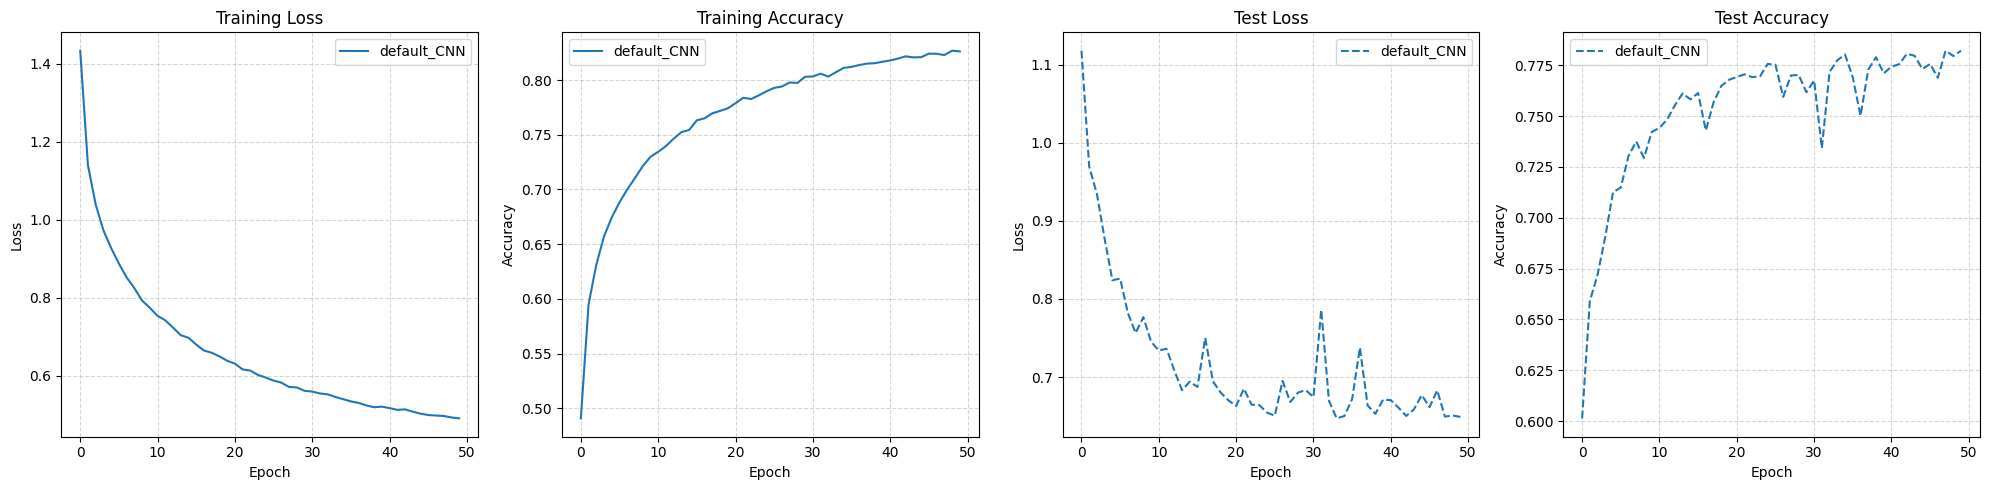

In [6]:
# 默认配置 
default_config = {
    'name': 'default_CNN',
    'conv_channels': [32, 64],
    'kernel_size': 3,
    'pool_type': 'max',
    'activation': 'relu',
    'use_bn': True,
    'dropout_rate': 0.2, 
    'fc_sizes': [128],
    'batch_size': 128,
    'learning_rate': 1e-3
}

results = {}
model = create_model(default_config)
results['default'] = train_model(model, default_config, num_epochs=50)
plot_results(results)


Training KS_7x7              : 100%|██████████| 50/50 [05:37<00:00,  6.75s/it]


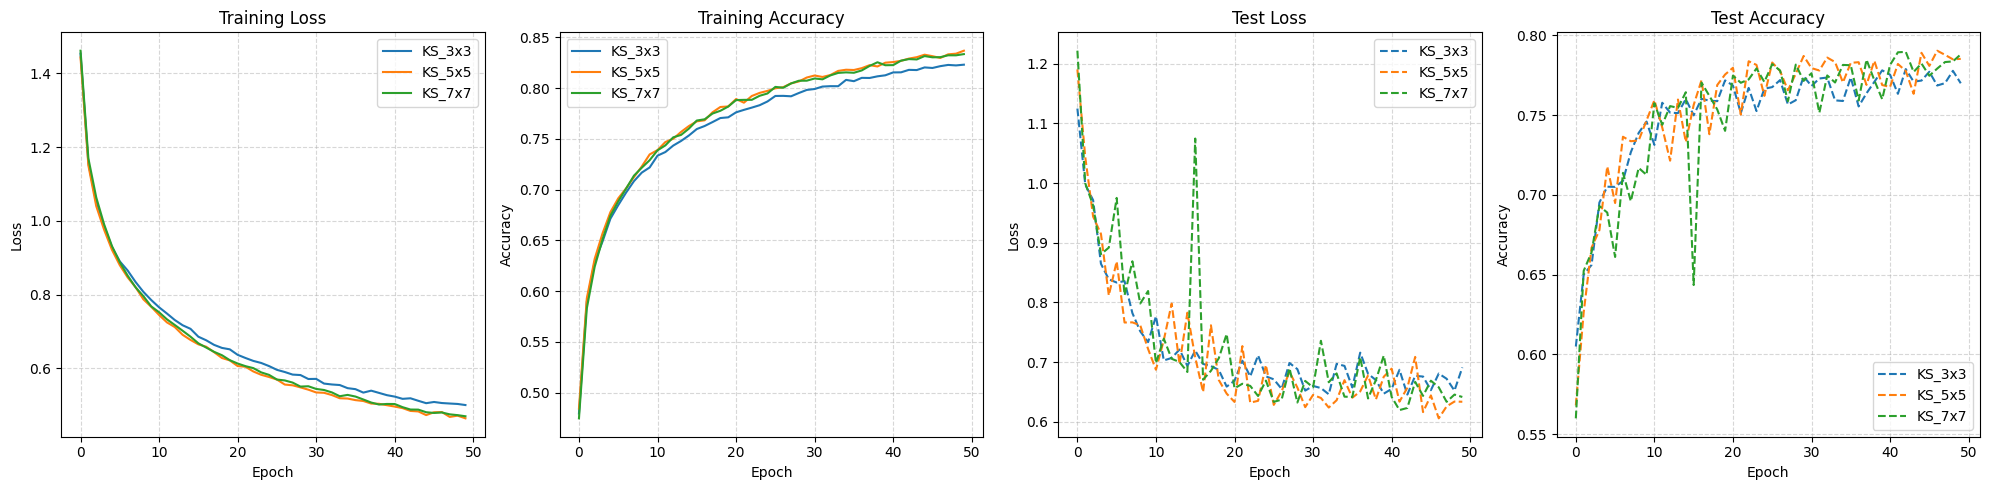

In [7]:
# 实验1: 不同卷积核大小
configs = {
    'cfg1': {
        'name': 'KS_3x3',
        'kernel_size': 3
    },
    'cfg2': {
        'name': 'KS_5x5',
        'kernel_size': 5
    },
    'cfg3': {
        'name': 'KS_7x7',
        'kernel_size': 7
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training CH_32_64_128        : 100%|██████████| 50/50 [06:14<00:00,  7.49s/it]


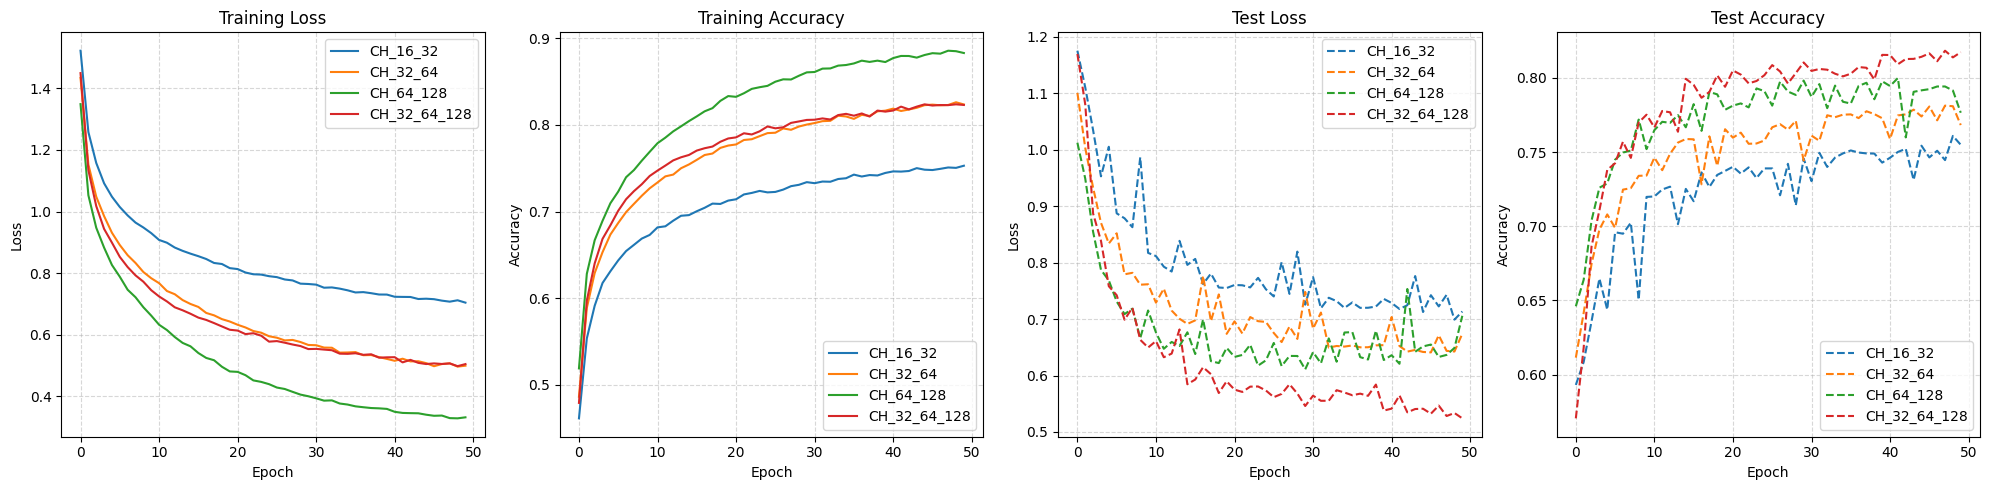

In [8]:
# 实验2: 不同通道数
configs = {
    'cfg1': {
        'name': 'CH_16_32',
        'conv_channels': [16, 32]
    },
    'cfg2': {
        'name': 'CH_32_64',
        'conv_channels': [32, 64]
    },
    'cfg3': {
        'name': 'CH_64_128',
        'conv_channels': [64, 128]
    },
    'cfg4': {
        'name': 'CH_32_64_128',
        'conv_channels': [32, 64, 128]
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training Pool_Avg            : 100%|██████████| 50/50 [05:12<00:00,  6.24s/it]


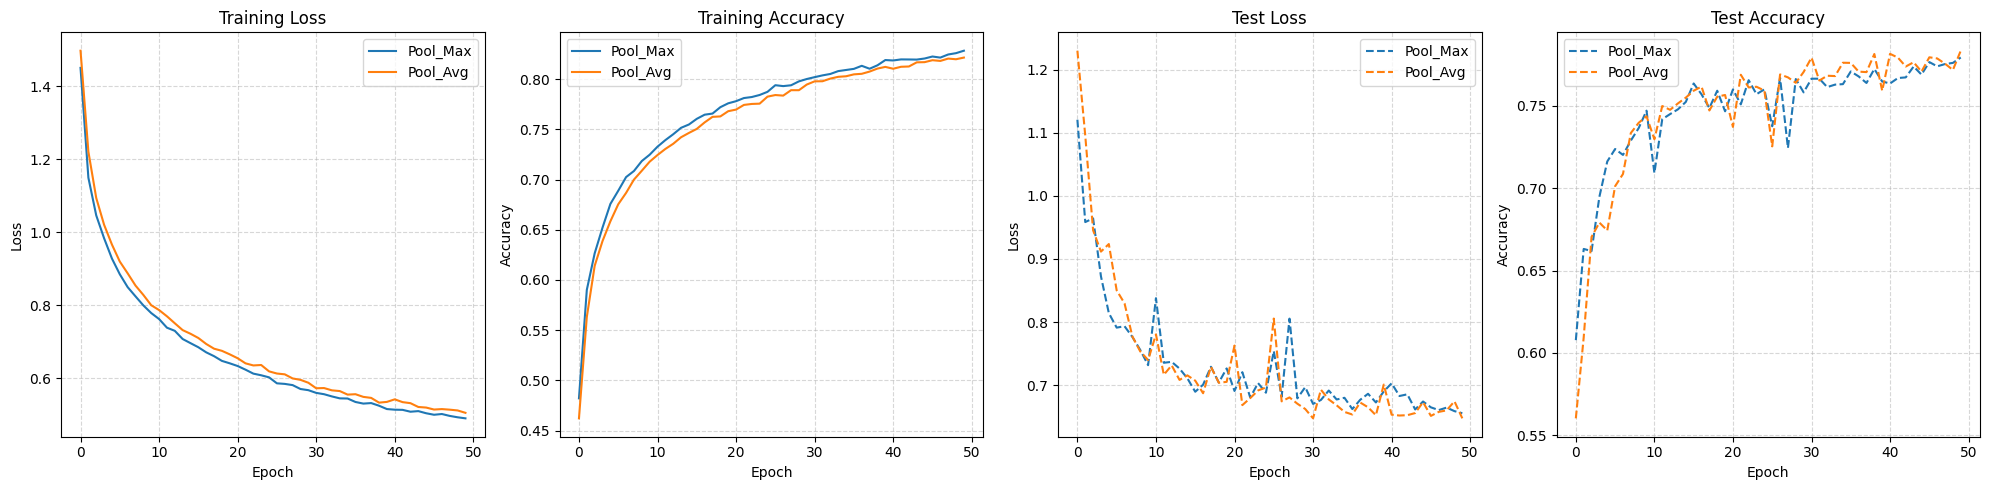

In [9]:
# 实验3: 不同池化方式
configs = {
    'cfg1': {
        'name': 'Pool_Max',
        'pool_type': 'max'
    },
    'cfg2': {
        'name': 'Pool_Avg',
        'pool_type': 'avg'
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training AF_ELU              : 100%|██████████| 50/50 [05:22<00:00,  6.45s/it]


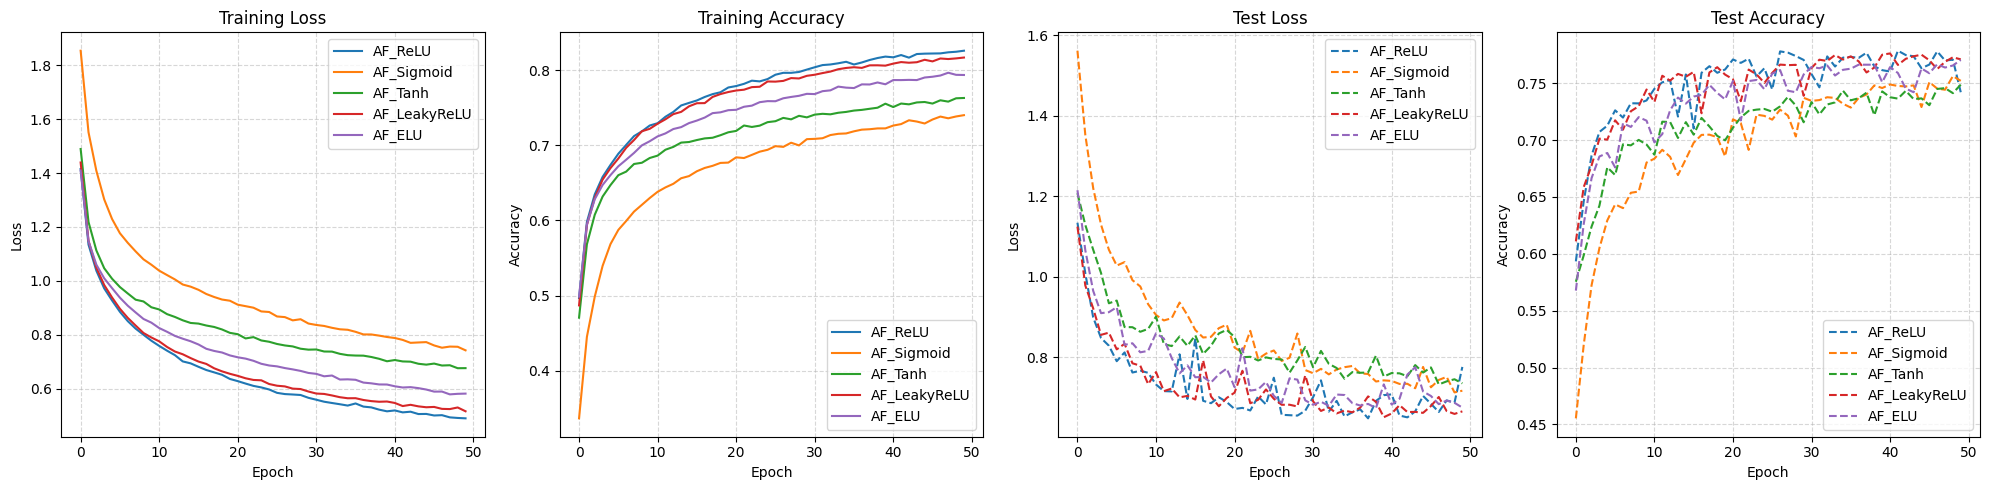

In [10]:
# 实验4: 不同激活函数
configs = {
    'cfg1': {
        'name': 'AF_ReLU',
        'activation': 'relu'
    },
    'cfg2': {
        'name': 'AF_Sigmoid',
        'activation': 'sigmoid'
    },
    'cfg3': {
        'name': 'AF_Tanh',
        'activation': 'tanh'
    },
    'cfg4': {
        'name': 'AF_LeakyReLU',
        'activation': 'leaky_relu'
    },
    'cfg5': {
        'name': 'AF_ELU',
        'activation': 'elu'
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training BN_True             : 100%|██████████| 50/50 [05:12<00:00,  6.25s/it]


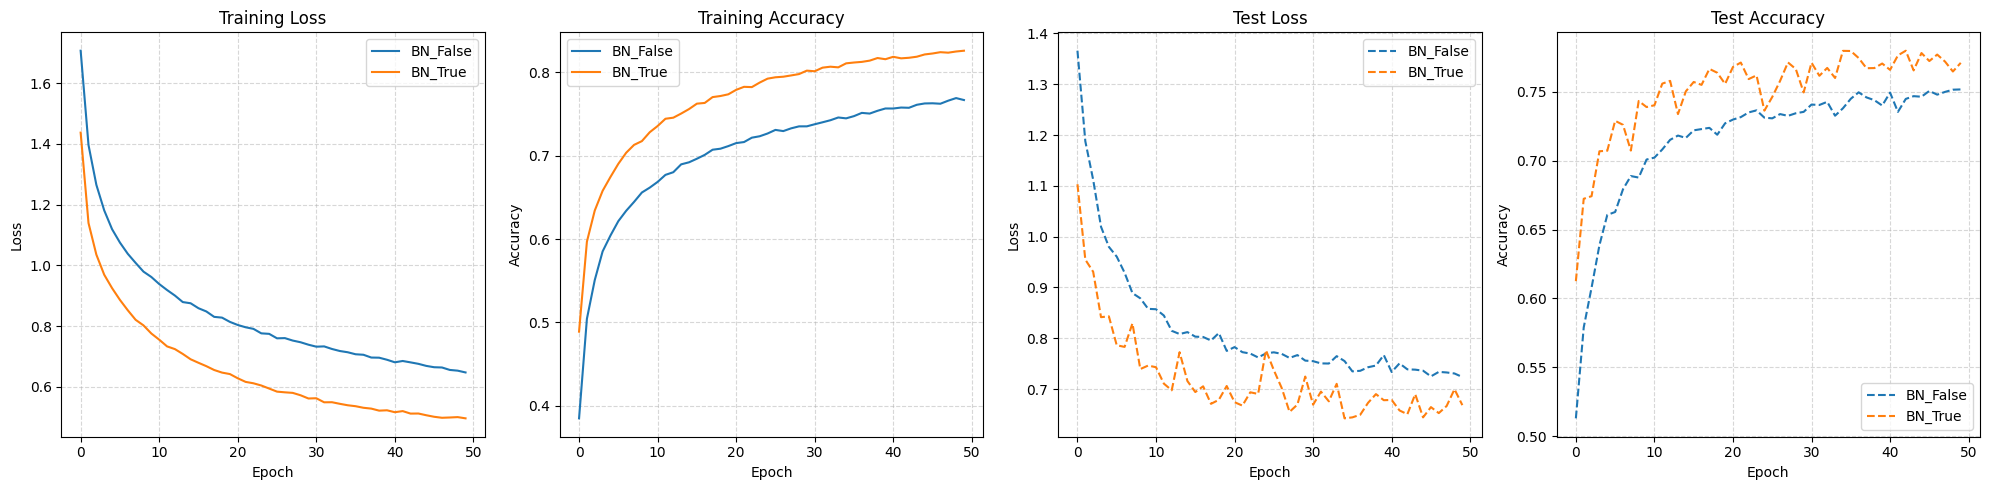

In [11]:
# 实验5: 批归一化的影响
configs = {
    'cfg1': {
        'name': 'BN_False',
        'use_bn': False
    },
    'cfg2': {
        'name': 'BN_True',
        'use_bn': True
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training Dropout_0.5         : 100%|██████████| 50/50 [05:07<00:00,  6.16s/it]


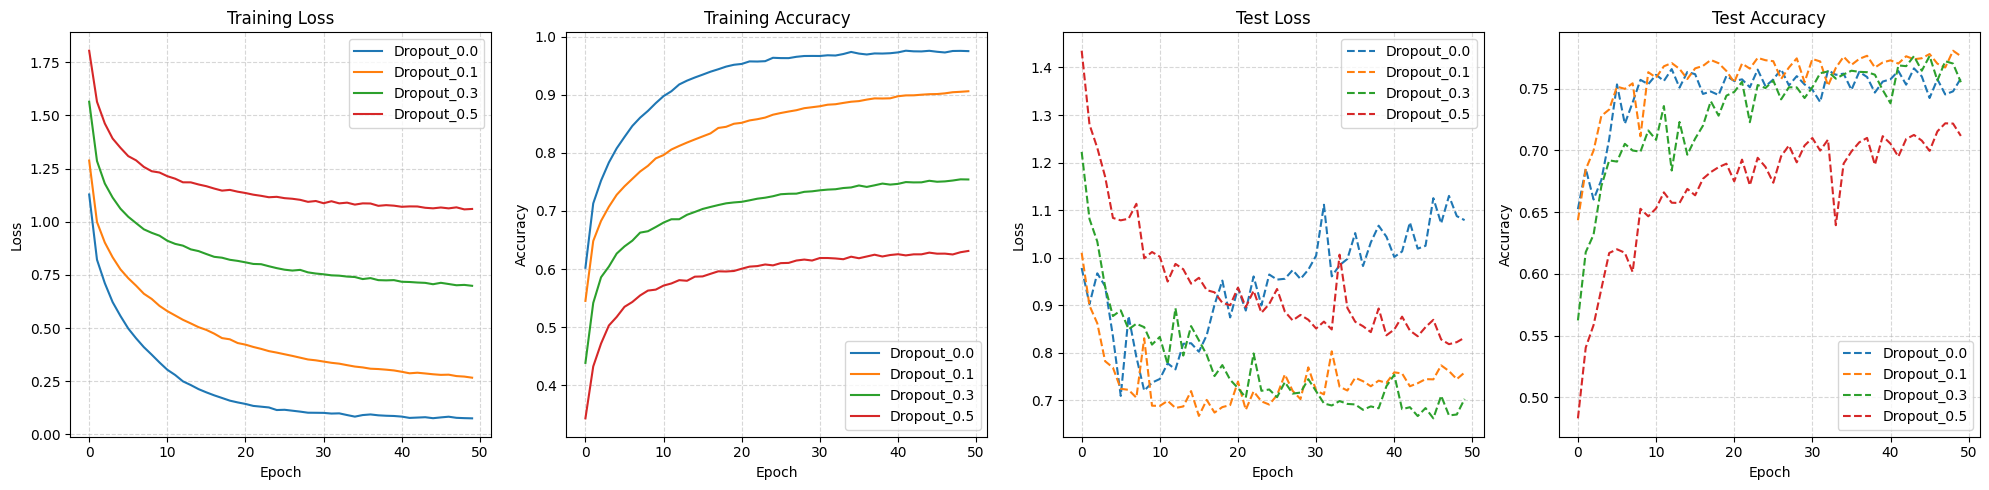

In [12]:
# 实验6: Dropout的影响
configs = {
    'cfg1': {
        'name': 'Dropout_0.0',
        'dropout_rate': 0.0
    },
    'cfg2': {
        'name': 'Dropout_0.1',
        'dropout_rate': 0.1
    },
    'cfg3': {
        'name': 'Dropout_0.3',
        'dropout_rate': 0.3
    },
    'cfg4': {
        'name': 'Dropout_0.5',
        'dropout_rate': 0.5
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)


Training FC_128_64           : 100%|██████████| 50/50 [06:06<00:00,  7.32s/it]


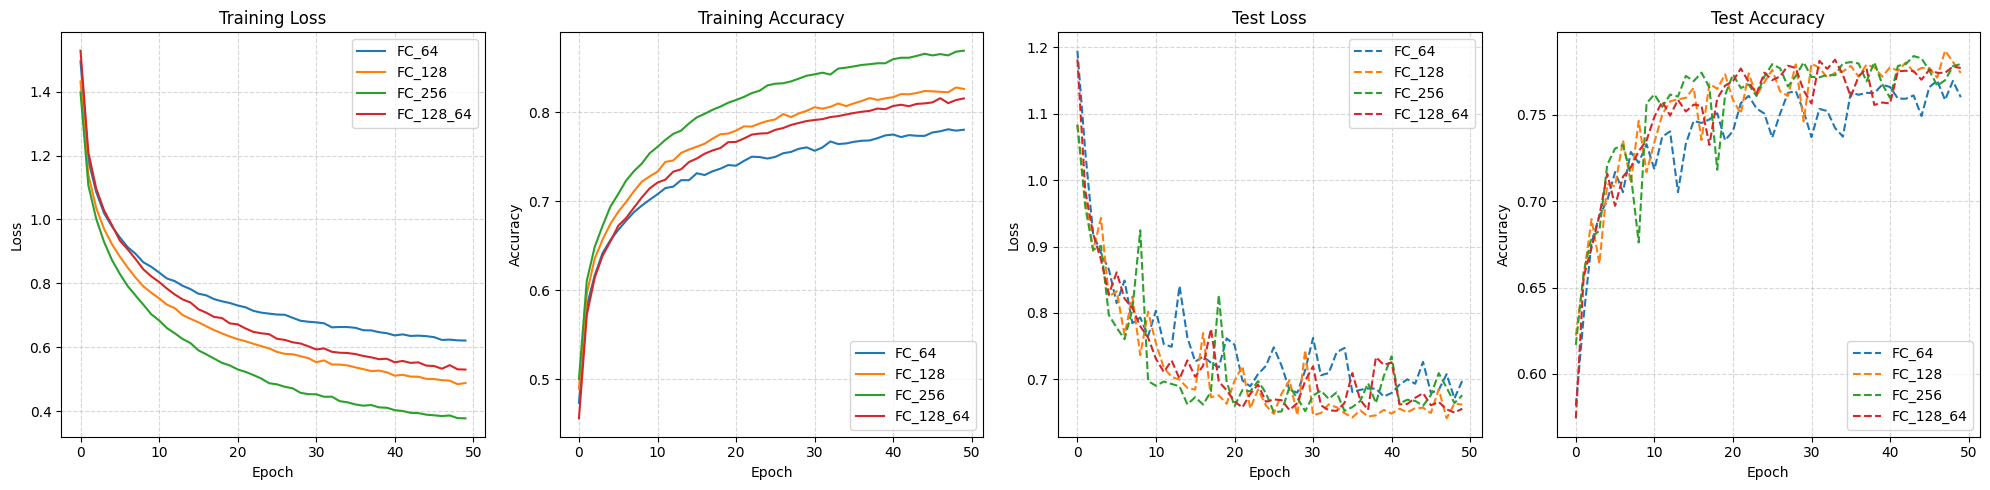

In [13]:
# 实验7: 全连接层大小
configs = {
    'cfg1': {
        'name': 'FC_64',
        'fc_sizes': [64]
    },
    'cfg2': {
        'name': 'FC_128',
        'fc_sizes': [128]
    },
    'cfg3': {
        'name': 'FC_256',
        'fc_sizes': [256]
    },
    'cfg4': {
        'name': 'FC_128_64',
        'fc_sizes': [128, 64]
    }
}

results = {}
for model_key, config in configs.items(): 
    model = create_model(config)
    results[model_key] = train_model(model, config, num_epochs=50)

plot_results(results)
